
════════════════════════════════════════════════════════════
  PAM PIPELINE  |  mode=saturation  metric=ETR (µmol e⁻ m⁻² s⁻¹)  group=per_species
════════════════════════════════════════════════════════════

Detected 24 groups across 4 species:
  SpeciesA     → 6 conditions, 2 reps each
  SpeciesB     → 6 conditions, 2 reps each
  SpeciesC     → 6 conditions, 2 reps each
  SpeciesD     → 6 conditions, 2 reps each


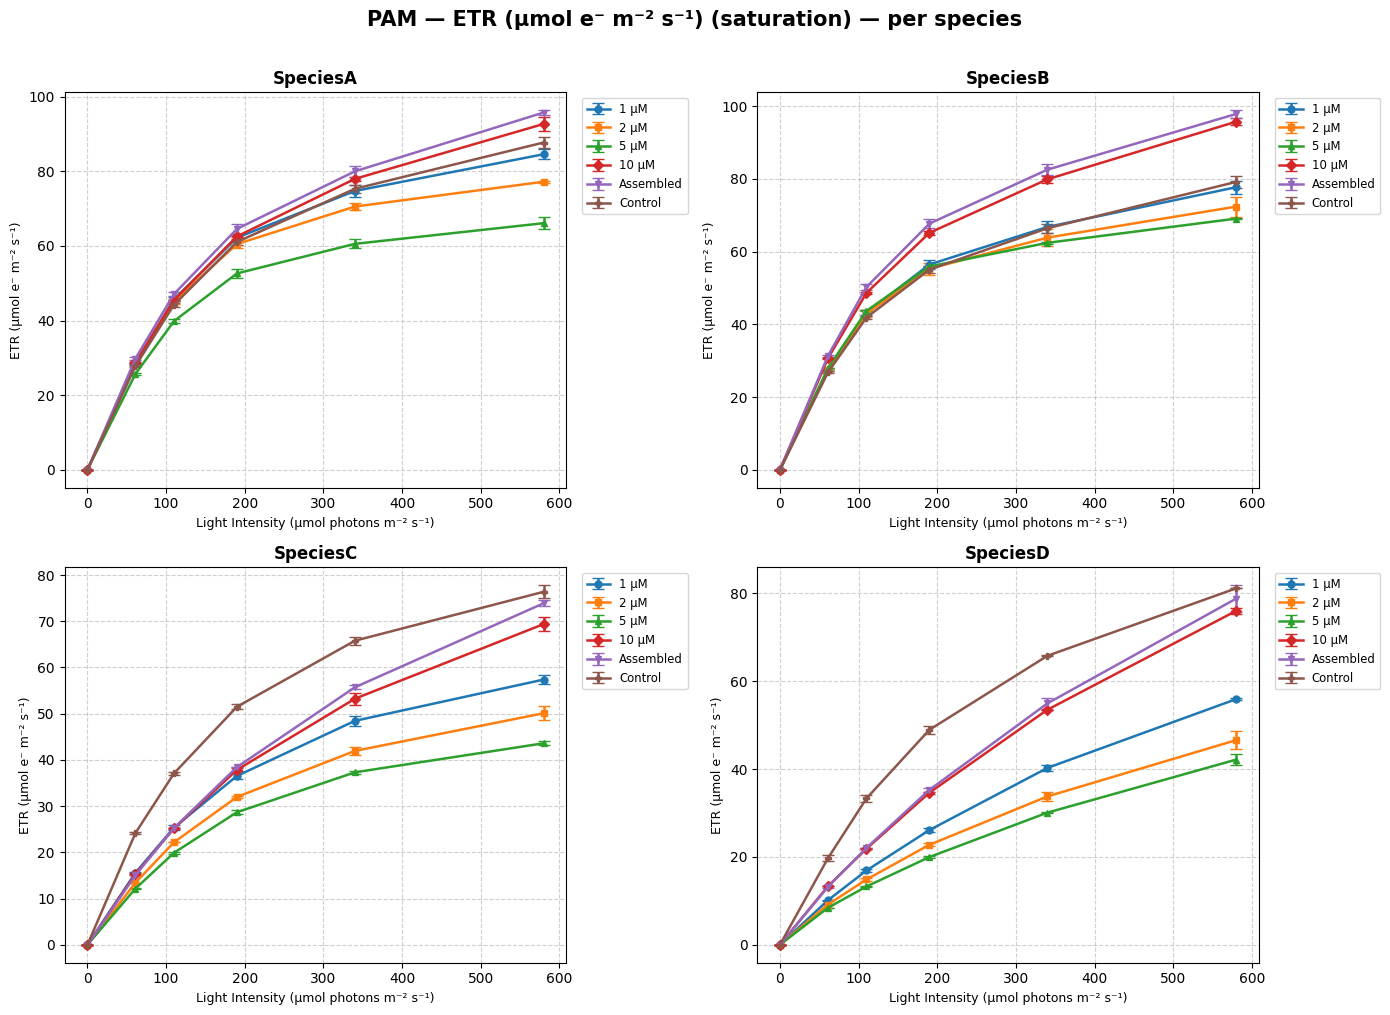


Done.


In [9]:
"""
╔══════════════════════════════════════════════════════════════════════════════╗
║                        PAM FLUOROMETRY PIPELINE                              ║
║                     Universal analysis & plotting script                     ║
╠══════════════════════════════════════════════════════════════════════════════╣
║  MODES                                                                       ║
║    "saturation"   — ETR / Y(II) / NPQ vs light intensity                     ║
║                     Supports 1 or 2 Excel files (merged as bio-replicates)   ║
║    "timecourse"   — ETR / Y(II) / NPQ vs time                                ║
║                     Single Excel file, Time column in ms → converted         ║
║                                                                              ║
║  COLUMN NAMING CONVENTION (required for auto-detection)                      ║
║    <Species>_<Condition>_<Rep>                                               ║
║    e.g.  SpeciesA_Control_1 | StrainB_10uM_2 | Mutant_Assembled_3            ║
║    The x-axis column must be named  "Light"  or  "Time"                      ║
║                                                                              ║
║  OUTPUT MODES                                                                ║
║    GROUP_MODE = "per_species"   → one subplot per species prefix             ║
║    GROUP_MODE = "per_condition" → one subplot per unique condition suffix    ║
║    GROUP_MODE = "combined"      → all curves on a single plot                ║
╚══════════════════════════════════════════════════════════════════════════════╝
"""

# ═══════════════════════════════════════════════════════════════════════════════
#  USER CONFIGURATION  ← only block you ever need to edit
# ═══════════════════════════════════════════════════════════════════════════════

MODE        = "saturation"      # "saturation" | "timecourse"
METRIC      = "ETR (µmol e⁻ m⁻² s⁻¹)"             # Label printed on the y-axis (ETR / NPQ / Y(II)) 
                                                  # Light Intensity (µmol photons m⁻² s⁻¹), Electron Transport Rate (µmol e⁻ m⁻² s⁻¹)

# --- Input files ---
# For saturation:   provide EXCEL_FILES as a list of 1 or 2 paths
#                   (2 files → bio-replicates merged on the Light column)
# For timecourse:   provide a single file; the Time column is expected in ms
EXCEL_FILES = [
    "dummy_excel.xlsx"
]
SHEET_NAME  = "LC"              # sheet name (same in all files)

# --- Grouping ---
# "per_species"   → subplot per species prefix
# "per_condition" → subplot per condition suffix
# "combined"      → single plot with all curves
GROUP_MODE  = "per_species"

# --- Y-axis limits (set to None for auto-scaling) ---
Y_LIM       = None              # e.g. (0, 125)  or  None

# --- Output & Styling ---
STYLE_MODE  = "categorical"     # "categorical" (high contrast) | "shades" | "hybrid"
SAVE_PLOTS  = False             # True → saves SVG; False → shows window
OUTPUT_DIR  = "."               # directory for saved SVGs

# ═══════════════════════════════════════════════════════════════════════════════
#  IMPORTS
# ═══════════════════════════════════════════════════════════════════════════════

import re
import sys
import math
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

# ═══════════════════════════════════════════════════════════════════════════════
#  STYLE ENGINE
#  Dynamically assigns colour, linestyle, and marker to every (species, condition)
#  pair. Behaviour adapts to GROUP_MODE so curves are always visually distinct
#  within each subplot regardless of which axis is being varied.
#
#  STYLE_MODE options:
#    "categorical" — high-contrast tab10 colours, one colour per curve within
#                    each subplot. Best default for most datasets.
#    "shades"      — single hue per species, lightness scaled by concentration.
#                    Good for per_species plots with a clear dose–response.
#    "hybrid"      — cycles linestyles first, then lightens. Useful when there
#                    are more conditions than tab10 slots.
# ═══════════════════════════════════════════════════════════════════════════════

_TAB10      = [matplotlib.colors.to_hex(c) for c in plt.cm.tab10.colors]
_LINESTYLES = ['-', '--', '-.', ':']
_MARKERS    = ['o', 's', '^', 'D', 'v', 'P', 'X']

def _lighten(hex_color: str, amount: float) -> str:
    """Lighten a hex colour by blending toward white."""
    rgb = matplotlib.colors.to_rgb(hex_color)
    return matplotlib.colors.to_hex(
        tuple(min(1.0, c + (1.0 - c) * amount) for c in rgb)
    )

def build_style_map(
    species_list: list[str],
    condition_list: list[str],
    style_mode: str = "categorical",
    group_mode: str = "per_species",
) -> dict[str, dict]:
    """
    Build a style map { 'Species_Condition': {'color', 'linestyle', 'marker'} }.
    Colour logic per style_mode × group_mode:
      categorical + per_species   → tab10 index = condition index
                                    (each condition gets a distinct colour per subplot)
      categorical + per_condition → tab10 index = species index
                                    (each species gets a distinct colour per subplot)
      categorical + combined      → tab10 index = species × n_conds + condition index
                                    (unique colour for every curve globally)
      shades                      → base colour per species, lightness ∝ condition rank
      hybrid                      → linestyle cycles first, then lightens base colour
    """
    style_map: dict[str, dict] = {}
    n_conds = len(condition_list)
    
    for species_idx, species in enumerate(species_list):
        base_color = _TAB10[species_idx % len(_TAB10)]
        for cond_idx, cond in enumerate(condition_list):
            marker = _MARKERS[cond_idx % len(_MARKERS)]
            
            if style_mode == "categorical":
                if group_mode == "per_condition":
                    color = _TAB10[species_idx % len(_TAB10)]
                elif group_mode == "combined":
                    color = _TAB10[(species_idx * n_conds + cond_idx) % len(_TAB10)]
                else:  # per_species
                    color = _TAB10[cond_idx % len(_TAB10)]
                ls = '-'
            elif style_mode == "shades":
                amount = (cond_idx / max(n_conds - 1, 1)) * 0.75
                color  = _lighten(base_color, amount)
                ls     = '-'
            else:  # "hybrid"
                ls            = _LINESTYLES[cond_idx % len(_LINESTYLES)]
                lighten_cycle = cond_idx // len(_LINESTYLES)
                color = _lighten(base_color, lighten_cycle * 0.25) if lighten_cycle > 0 else base_color
                
            style_map[f"{species}_{cond}"] = {
                'color': color, 'linestyle': ls, 'marker': marker
            }
            
    return style_map

# ═══════════════════════════════════════════════════════════════════════════════
#  DATA LOADING
# ═══════════════════════════════════════════════════════════════════════════════

def _read_file(path: str, sheet: str) -> pd.DataFrame:
    """
    Dispatch to pd.read_csv or pd.read_excel based on file extension.
    Normalises any capitalisation of 'Light' and 'Time' after loading.
    """
    p = path.strip().lower()
    if p.endswith(".csv"):
        df = pd.read_csv(path, header=0)
    elif p.endswith((".xlsx", ".xls", ".xlsm", ".ods")):
        df = pd.read_excel(path, sheet_name=sheet, header=0)
    else:
        raise ValueError(
            f"Unsupported file format: '{path}'. "
            "Expected .csv, .xlsx, .xls, .xlsm, or .ods."
        )
        
    col_map = {}
    for col in df.columns:
        if   col.lower() == "light": col_map[col] = "Light"
        elif col.lower() == "time":  col_map[col] = "Time"
    if col_map:
        df = df.rename(columns=col_map)
    return df

def _load_saturation(files: list[str], sheet: str) -> tuple[pd.Series, pd.DataFrame]:
    """
    Load 1 or 2 files and merge on 'Light'.
    Two files → second file columns get _b suffix (bio-replicate day 2).
    Light values are rounded to 1 decimal place before merging to avoid
    float-precision mismatches between instruments.
    """
    dfs = [_read_file(f, sheet) for f in files]
    if len(dfs) == 1:
        df = dfs[0]
    else:
        dfs[1] = dfs[1].rename(
            columns={c: c + "_b" for c in dfs[1].columns if c != "Light"}
        )
        dfs[0]["Light"] = dfs[0]["Light"].round(1)
        dfs[1]["Light"] = dfs[1]["Light"].round(1)
        df = pd.merge(dfs[0], dfs[1], on="Light", how="outer")
    return df["Light"], df.drop(columns=["Light"])

def _load_timecourse(files: list[str], sheet: str) -> tuple[pd.Series, pd.DataFrame]:
    """
    Load a single file with a 'Time' column (ms → min).
    """
    if len(files) != 1:
        raise ValueError("timecourse mode expects exactly one file.")
    df = _read_file(files[0], sheet)
    if "Time" not in df.columns:
        raise ValueError(
            "No 'Time' column found (case-insensitive search also failed). "
            "Ensure the x-axis column is named 'Time' (or any capitalisation)."
        )
    time_min = df["Time"] / 60_000
    return time_min, df.drop(columns=["Time"])

# ═══════════════════════════════════════════════════════════════════════════════
#  AUTO-DETECTION OF SAMPLES
#  Expected column pattern:  <Species>_<Condition>_<Rep>[_b]
#  e.g.  SpeciesA_Control_1 | CC_10_uM_2 | CW_Assembled_1_b
# ═══════════════════════════════════════════════════════════════════════════════

def _strip_rep(col: str) -> str:
    """Remove replicate index and day-suffix: SpeciesA_Control_1_b → SpeciesA_Control"""
    col = re.sub(r"_b$",  "", col)
    col = re.sub(r"_\d+$", "", col)
    return col

def _parse_column(col: str) -> tuple[str, str] | None:
    """Return (species, condition) or None for unrecognised columns."""
    base  = _strip_rep(col)
    parts = base.split("_", 1)
    if len(parts) < 2:
        return None
    return parts[0], parts[1]

def detect_samples(data_df: pd.DataFrame) -> dict[str, list[str]]:
    """
    Auto-detect all sample groups from column names.
    Returns { 'Species_Condition': [col1, col2, …] }.
    Columns that do not match the naming convention are reported and skipped.
    """
    groups: dict[str, list[str]] = defaultdict(list)
    for col in data_df.columns:
        parsed = _parse_column(col)
        if parsed is None:
            print(f"  WARNING: Dropping column '{col}' — does not match "
                  "<Species>_<Condition>_<Rep> format.")
            continue
        groups[f"{parsed[0]}_{parsed[1]}"].append(col)
    return dict(groups)

def get_species_and_conditions(
    groups: dict[str, list[str]]
) -> tuple[list[str], list[str]]:
    """Extract ordered unique species prefixes and condition suffixes."""
    species_set: list[str] = []
    cond_set:    list[str] = []
    for key in groups:
        sp, cond = key.split("_", 1)
        if sp   not in species_set: species_set.append(sp)
        if cond not in cond_set:    cond_set.append(cond)

    cond_set.sort(key=lambda s: [int(t) if t.isdigit() else t for t in re.split(r'(\d+)', s)])
    return species_set, cond_set

# ═══════════════════════════════════════════════════════════════════════════════
#  TIMECOURSE HELPER
# ═══════════════════════════════════════════════════════════════════════════════

def melt_timecourse(
    x: pd.Series,
    data_df: pd.DataFrame,
    x_name: str = "Time(min)",
) -> pd.DataFrame:
    """Return a long-form DataFrame: [x_name, Species, Condition, value]."""
    df        = data_df.copy()
    df[x_name] = x.values
    melted    = df.melt(id_vars=[x_name], var_name="_col", value_name="value")
    melted["_base"] = melted["_col"].apply(_strip_rep)
    melted[["Species", "Condition"]] = (
        melted["_base"].str.split("_", n=1, expand=True)
    )
    return melted.drop(columns=["_col", "_base"])

# ═══════════════════════════════════════════════════════════════════════════════
#  GRIDDED PLOT LAYOUT HELPER
# ═══════════════════════════════════════════════════════════════════════════════

def _make_grid(n: int) -> tuple[int, int]:
    """Return (nrows, ncols) for n subplots, preferring wide layouts."""
    if n == 1:
        return 1, 1
    ncols = math.ceil(math.sqrt(n))
    return math.ceil(n / ncols), ncols

# ═══════════════════════════════════════════════════════════════════════════════
#  CORE PLOTTING FUNCTION
# ═══════════════════════════════════════════════════════════════════════════════

def _format_label(text: str) -> str:
    """Turn internal condition strings into pretty legend labels."""
    return text.replace("_uM", " µM").replace("_", " ")

def plot_grid(
    x: pd.Series,
    data_df: pd.DataFrame | None,
    groups: dict[str, list[str]],
    style_map: dict[str, dict],
    subplot_keys: list[str],
    subplot_title_fn,
    curve_keys_fn,
    curve_label_fn,
    x_label: str,
    y_label: str,
    panel_title: str,
    y_lim=None,
    long_df: pd.DataFrame | None = None,
    x_col: str = "Time(min)",
    mode: str = "saturation",
) -> plt.Figure:
    """
    Universal grid plotter — fully agnostic to GROUP_MODE and MODE.
    Saturation → errorbar with SD caps.
    Timecourse  → line + shaded SD band (lower bound clamped to zero).
    """
    n = len(subplot_keys)
    nrows, ncols = _make_grid(n)
    fig, _ = plt.subplots(nrows, ncols, figsize=(max(7 * ncols, 10), max(5 * nrows, 6)))
    
    # fig.axes is always a flat list regardless of grid shape
    axes_flat = np.array(fig.axes)
    
    for idx, key in enumerate(subplot_keys):
        ax         = axes_flat[idx]
        curve_keys = curve_keys_fn(key, groups)
        
        if mode == "saturation":
            for gkey in curve_keys:
                cols = groups.get(gkey)
                if not cols:
                    continue
                mean_vals = data_df[cols].mean(axis=1)
                sd_vals   = data_df[cols].std(axis=1)
                style     = style_map.get(gkey, {'color': 'grey', 'linestyle': '-', 'marker': 'o'})
                
                ax.errorbar(
                    x, mean_vals, yerr=sd_vals,
                    marker=style['marker'], capsize=4, linewidth=1.8, markersize=5,
                    label=curve_label_fn(gkey),
                    color=style['color'], linestyle=style['linestyle'],
                )
        else:  # timecourse
            for gkey in curve_keys:
                sp, cond = gkey.split("_", 1)
                sub = long_df[
                    (long_df["Species"] == sp) & (long_df["Condition"] == cond)
                ]
                if sub.empty:
                    continue
                grp       = sub.groupby(x_col)["value"]
                mean_vals = grp.mean()
                sd_vals   = grp.std()
                style     = style_map.get(gkey, {'color': 'grey', 'linestyle': '-', 'marker': 'o'})
                
                ax.plot(
                    mean_vals.index, mean_vals.values,
                    marker=style['marker'], linewidth=1.8, markersize=4,
                    label=curve_label_fn(gkey),
                    color=style['color'], linestyle=style['linestyle'],
                )
                lower_bound = np.maximum(0, mean_vals - sd_vals)
                ax.fill_between(
                    mean_vals.index, lower_bound, mean_vals + sd_vals,
                    alpha=0.2, color=style['color'],
                )
                
        ax.set_title(subplot_title_fn(key), fontsize=12, fontweight="bold")
        ax.set_xlabel(x_label, fontsize=9)
        ax.set_ylabel(y_label, fontsize=9)
        ax.grid(True, linestyle="--", alpha=0.6)
        if y_lim is not None:
            ax.set_ylim(y_lim)
        ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize="small")
        
    for idx in range(n, len(axes_flat)):
        axes_flat[idx].set_visible(False)
        
    fig.suptitle(panel_title, fontsize=15, fontweight="bold", y=1.01)
    plt.tight_layout()
    return fig

# ═══════════════════════════════════════════════════════════════════════════════
#  SAVE / SHOW
# ═══════════════════════════════════════════════════════════════════════════════

def save_or_show(fig, fname: str, save: bool = False, output_dir: str = "."):
    """Save to SVG or display interactively. All globals passed explicitly."""
    if save:
        out  = Path(output_dir)
        out.mkdir(parents=True, exist_ok=True)
        safe = (
            fname.replace(" ", "_").replace("/", "_")
                 .replace("µ", "u").replace("⁻", "-")
        ) + ".svg"
        path = out / safe
        fig.savefig(path, dpi=1200, bbox_inches="tight")
        print(f"Saved → {path}")
    else:
        plt.show()
    plt.close(fig)

# ═══════════════════════════════════════════════════════════════════════════════
#  GROUPING STRATEGY BUILDERS
#  Each builder returns (subplot_keys, title_fn, curve_keys_fn, curve_label_fn).
#  plot_grid is fully agnostic — swap the builder to change layout.
# ═══════════════════════════════════════════════════════════════════════════════

def _build_per_species(species_list, cond_list, groups):
    """One subplot per species; curves = conditions."""
    subplot_keys   = species_list
    title_fn       = lambda sp: sp
    curve_keys_fn  = lambda sp, grps: [f"{sp}_{c}" for c in cond_list if f"{sp}_{c}" in grps]
    curve_label_fn = lambda gkey: _format_label(gkey.split("_", 1)[1])
    return subplot_keys, title_fn, curve_keys_fn, curve_label_fn

def _build_per_condition(species_list, cond_list, groups):
    """One subplot per condition; curves = species."""
    subplot_keys   = cond_list
    title_fn       = lambda cond: _format_label(cond)
    curve_keys_fn  = lambda cond, grps: [f"{sp}_{cond}" for sp in species_list if f"{sp}_{cond}" in grps]
    curve_label_fn = lambda gkey: gkey.split("_", 1)[0]
    return subplot_keys, title_fn, curve_keys_fn, curve_label_fn

def _build_combined(species_list, cond_list, groups):
    """Single subplot with all curves."""
    subplot_keys   = ["All"]
    title_fn       = lambda _: "All conditions"
    curve_keys_fn  = lambda _, grps: list(grps.keys())
    curve_label_fn = lambda gkey: _format_label(gkey)
    return subplot_keys, title_fn, curve_keys_fn, curve_label_fn

# ═══════════════════════════════════════════════════════════════════════════════
#  MAIN
# ═══════════════════════════════════════════════════════════════════════════════

def main():
    print(f"\n{'═'*60}")
    print(f"  PAM PIPELINE  |  mode={MODE}  metric={METRIC}  group={GROUP_MODE}")
    print(f"{'═'*60}\n")
    
    # ── Load ───────────────────────────────────────────────────
    if MODE == "saturation":
        x, data_df = _load_saturation(EXCEL_FILES, SHEET_NAME)
        x_label    = "Light Intensity (µmol photons m⁻² s⁻¹)"
        x_col      = "Light"
        long_df    = None
    elif MODE == "timecourse":
        x, data_df = _load_timecourse(EXCEL_FILES, SHEET_NAME)
        x_label    = "Time (min)"
        x_col      = "Time(min)"
        long_df    = melt_timecourse(x, data_df, x_name=x_col)
    else:
        sys.exit(f"Unknown MODE '{MODE}'. Use 'saturation' or 'timecourse'.")
        
    # ── Auto-detect ────────────────────────────────────────────
    groups = detect_samples(data_df)
    if not groups:
        sys.exit("No sample columns detected. Check column naming convention.")
        
    species_list, cond_list = get_species_and_conditions(groups)
    print(f"Detected {len(groups)} groups across {len(species_list)} species:")
    for sp in species_list:
        sp_groups = [k for k in groups if k.startswith(sp + "_")]
        print(f"  {sp:12s} → {len(sp_groups)} conditions, "
              f"{len(groups[sp_groups[0]])} reps each")
              
    # ── Style ──────────────────────────────────────────────────
    style_map = build_style_map(species_list, cond_list, STYLE_MODE, GROUP_MODE)
    
    # ── Grouping strategy ──────────────────────────────────────
    builders = {
        "per_species":   _build_per_species,
        "per_condition": _build_per_condition,
        "combined":      _build_combined,
    }
    
    if GROUP_MODE not in builders:
        sys.exit(f"Unknown GROUP_MODE '{GROUP_MODE}'. "
                 "Use 'per_species', 'per_condition', or 'combined'.")
                 
    subplot_keys, title_fn, curve_keys_fn, curve_label_fn = builders[GROUP_MODE](
        species_list, cond_list, groups
    )
    
    panel_title = f"PAM — {METRIC} ({MODE}) — {GROUP_MODE.replace('_', ' ')}"
    fname       = f"pam_{METRIC}_{MODE}_{GROUP_MODE}"
    
    # ── Plot ───────────────────────────────────────────────────
    fig = plot_grid(
        x                = x,
        data_df          = data_df if MODE == "saturation" else None,
        groups           = groups,
        style_map        = style_map,
        subplot_keys     = subplot_keys,
        subplot_title_fn = title_fn,
        curve_keys_fn    = curve_keys_fn,
        curve_label_fn   = curve_label_fn,
        x_label          = x_label,
        y_label          = METRIC,
        panel_title      = panel_title,
        y_lim            = Y_LIM,
        long_df          = long_df,
        x_col            = x_col,
        mode             = MODE,
    )
    
    save_or_show(fig, fname, SAVE_PLOTS, OUTPUT_DIR)
    print("\nDone.")

if __name__ == "__main__":
    main()